In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error

In [3]:
df=pd.read_csv("Salary_dataset.csv")
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


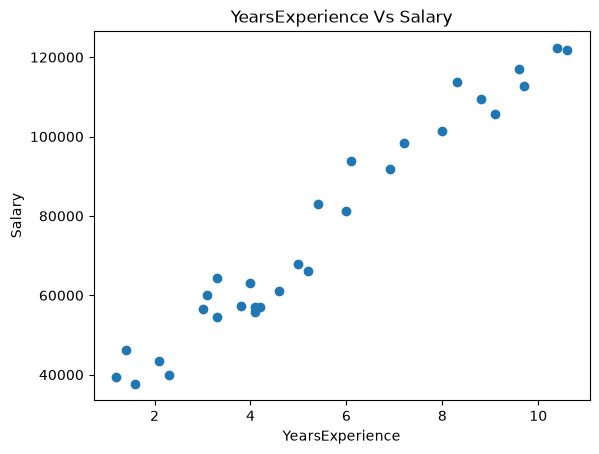

In [5]:
plt.scatter(df['YearsExperience'],df['Salary'])
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.title('YearsExperience Vs Salary')
plt.show()             # It show that data is Linear data

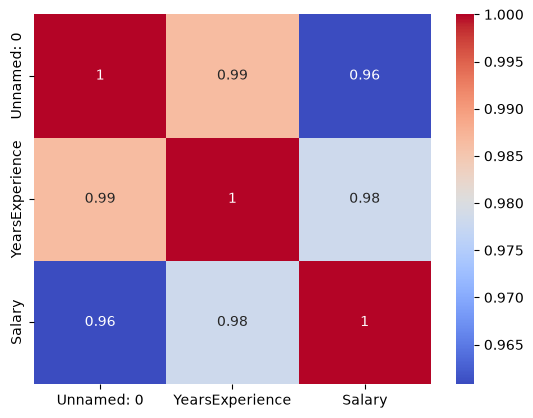

In [6]:
corr =df.corr(numeric_only= True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

***Defining x and y***

In [7]:
x=df[['YearsExperience']]
y=df['Salary']

**Train_test_split**

In [8]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [9]:
df.corr()

,Unnamed: 0,YearsExperience,Salary
Unnamed: 0,1.000000,0.986460,0.960826
YearsExperience,0.986460,1.000000,0.978242
Salary,0.960826,0.978242,1.000000


**Model Creation**

In [10]:
model= LinearRegression()
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.438e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


**Model Evaluation**

In [11]:
ytrain_pedicted=model.predict(xtrain)
ytrain_pedicted


array([122387.880839  , 107309.77632215,  63017.8443039 ,  35688.77986711,
        46054.97672244,  73384.04115923,  52651.64744857,  63960.2258362 ,
        63017.8443039 ,  99770.72406372,  37573.54293172,  39458.30599632,
       110136.92091906,  44170.21365784,  92231.6718053 , 114848.82858057,
        80923.09341766, 124272.6439036 ,  89404.52720839,  55478.79204548,
        62075.4627716 ,  67729.75196542,  81865.47494996,  53594.02898087])

In [12]:
# Model Training

print(r2_score(ytrain,ytrain_pedicted))
print(mean_absolute_error(ytrain,ytrain_pedicted))
print(root_mean_squared_error(ytrain,ytrain_pedicted))


0.9645401573418148
4221.046734449733
5205.982110155715


In [13]:
ytest_predicted=model.predict(xtest)
ytest_predicted

array([115791.21011287,  71499.27809463, 102597.86866063,  75268.80422384,
        55478.79204548,  60190.69970699])

In [14]:
# Model Testing

print(r2_score(ytest,ytest_predicted))
print(mean_absolute_error(ytest,ytest_predicted))
print(root_mean_squared_error(ytest,ytest_predicted))

0.9024461774180498
6286.453830757745
7059.043621901506


# Overall Conclusion

The regression model performed well, achieving an R2_score of 96.4%, MAE of 4221, and RMSE of 5205.
These result indicate that the model makes reasonanly accurate predictions with relatively few large errors,demonstrating good overall performance.